# Brain Tumor MRI Classification, Medical Preprocessing Engine & Visual Explainability
### End-to-End Deep Learning & Image Processing Pipeline for UOP Ada GPU Server
**Course Project:** Image Processing & Computer Vision  
**Target Hardware Environment:** PyTorch CUDA Acceleration (NVIDIA Ada GPU / RTX Server)  
**Dataset:** Public Brain Tumor MRI Dataset (`Glioma`, `Meningioma`, `Pituitary`, `No Tumor`)

---

## Phase 1: Environment Setup & Ada GPU Server Diagnostics
This section automatically installs required dependencies on Ada Server, initializes libraries, sets a global seed (`42`) for experiment reproducibility, and checks CUDA hardware specs.

In [ ]:
# Automated Dependency Resolution for Ada GPU Server
!pip install  albumentations timm torchinfo thop scikit-learn seaborn opencv-python matplotlib

In [17]:
import os
import sys
import time
import json
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Global Reproducibility Seed
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Hardware Acceleration Diagnostic
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 60)
print(f"[System Diagnostic] Python Version : {sys.version.split()[0]}")
print(f"[System Diagnostic] PyTorch Version: {torch.__version__}")
print(f"[System Diagnostic] Target Device  : {device}")
if torch.cuda.is_available():
    print(f"[System Diagnostic] GPU Model Name : {torch.cuda.get_device_name(0)}")
    print(f"[System Diagnostic] CUDA Capability: {torch.cuda.get_device_capability(0)}")
    print(f"[System Diagnostic] Total VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("[System Diagnostic] WARNING: Running on CPU. CUDA recommended for Ada Server training.")
print("=" * 60)

[System Diagnostic] Python Version : 3.12.3
[System Diagnostic] PyTorch Version: 2.13.0+cu130
[System Diagnostic] Target Device  : cuda
[System Diagnostic] GPU Model Name : NVIDIA RTX 6000 Ada Generation
[System Diagnostic] CUDA Capability: (8, 9)
[System Diagnostic] Total VRAM    : 50.87 GB


## Phase 2: Dataset Setup & Reproducible Stratified Splitting
We discover the `archive/` dataset containing MRI scans across 4 classes (`glioma`, `meningioma`, `notumor`, `pituitary`).  
- **Test Set**: Use the official `archive/Testing` set directly (1,600 scans: 400 per class).
- **Train / Validation Split**: Stratified 80% Train (4,480 scans) and 20% Validation (1,120 scans) split from `archive/Training` with fixed random seed `42`.

In [18]:
# Robust Dataset Path & Case-Insensitive Auto-Detection for Ada GPU Server (Linux)
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
CLASS_TO_IDX = {cls_name: i for i, cls_name in enumerate(CLASSES)}

def find_dataset_root():
    search_candidates = [
        "archive", "Archive",
        os.path.join(".", "archive"),
        os.path.join("..", "archive"),
        os.path.join("..", "..", "archive"),
        os.path.expanduser("~/projects/NN/archive"),
        os.path.expanduser("~/archive"),
    ]
    for cand in search_candidates:
        if os.path.exists(cand) and os.path.isdir(cand):
            contents = [c.lower() for c in os.listdir(cand)]
            if any(k in contents for k in ['training', 'train']):
                return cand
            if 'archive' in contents:
                nested = os.path.join(cand, 'archive')
                if os.path.isdir(nested):
                    nested_contents = [c.lower() for c in os.listdir(nested)]
                    if any(k in nested_contents for k in ['training', 'train']):
                        return nested
    for root, dirs, _ in os.walk("."):
        dirs_lower = [d.lower() for d in dirs]
        if 'training' in dirs_lower or 'train' in dirs_lower:
            return root
    return "archive"

DATASET_ROOT = find_dataset_root()

def get_case_insensitive_dir(parent_dir, target_name):
    if not os.path.exists(parent_dir):
        return None
    for entry in os.listdir(parent_dir):
        if entry.lower() == target_name.lower():
            return os.path.join(parent_dir, entry)
    return None

TRAIN_DIR = get_case_insensitive_dir(DATASET_ROOT, "Training") or get_case_insensitive_dir(DATASET_ROOT, "Train") or os.path.join(DATASET_ROOT, "Training")
TEST_DIR  = get_case_insensitive_dir(DATASET_ROOT, "Testing") or get_case_insensitive_dir(DATASET_ROOT, "Test") or os.path.join(DATASET_ROOT, "Testing")

def collect_filepaths(directory):
    paths, labels = [], []
    if not directory or not os.path.exists(directory):
        return np.array(paths), np.array(labels)
    
    subdirs = os.listdir(directory)
    for cls_name in CLASSES:
        target_dir = None
        for s in subdirs:
            cleaned_s = s.lower().replace("_", "").replace(" ", "").replace("-", "")
            cleaned_target = cls_name.lower().replace("_", "").replace(" ", "").replace("-", "")
            if cleaned_s == cleaned_target:
                target_dir = os.path.join(directory, s)
                break
        if target_dir and os.path.exists(target_dir):
            for root, _, files in os.walk(target_dir):
                for file_name in files:
                    if file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
                        paths.append(os.path.join(root, file_name))
                        labels.append(CLASS_TO_IDX[cls_name])
    return np.array(paths), np.array(labels)

raw_train_paths, raw_train_labels = collect_filepaths(TRAIN_DIR)
test_paths, test_labels = collect_filepaths(TEST_DIR)

if len(raw_train_paths) == 0:
    print(f"[ERROR] Found 0 training images!")
    print(f"Current Working Directory: {os.getcwd()}")
    print(f"Detected DATASET_ROOT: {DATASET_ROOT}")
    print(f"Resolved TRAIN_DIR   : {TRAIN_DIR}")
    print(f"Directory Contents of '{DATASET_ROOT}': {os.listdir(DATASET_ROOT) if os.path.exists(DATASET_ROOT) else 'Directory does not exist'}")
    raise RuntimeError(
        f"No training scans found in '{TRAIN_DIR}'. Please check that your 'archive' folder containing "
        f"'Training' and 'Testing' subdirectories is present in your project directory."
    )

# Perform Stratified Train/Val split (80/20) on archive/Training
tr_paths, val_paths, tr_labels, val_labels = train_test_split(
    raw_train_paths, raw_train_labels, test_size=0.20, stratify=raw_train_labels, random_state=42
)

# Calculate class imbalance weights for Loss Function
class_counts = np.bincount(tr_labels)
total_samples = len(tr_labels)
class_weights = total_samples / (len(CLASSES) * class_counts.astype(np.float32))
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f"--- Dataset Discovery Summary ---")
print(f"Dataset Root Dir : {DATASET_ROOT}")
print(f"Training Scans   : {len(tr_paths)} images")
print(f"Validation Scans : {len(val_paths)} images")
print(f"Official Test Set: {len(test_paths)} images")
print(f"Class Mapping    : {CLASS_TO_IDX}")
print(f"Computed Class Weights: {class_weights_tensor.cpu().numpy().round(4)}")

--- Dataset Discovery Summary ---
Dataset Root Dir : archive
Training Scans   : 4480 images
Validation Scans : 1120 images
Official Test Set: 1600 images
Class Mapping    : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Computed Class Weights: [1. 1. 1. 1.]


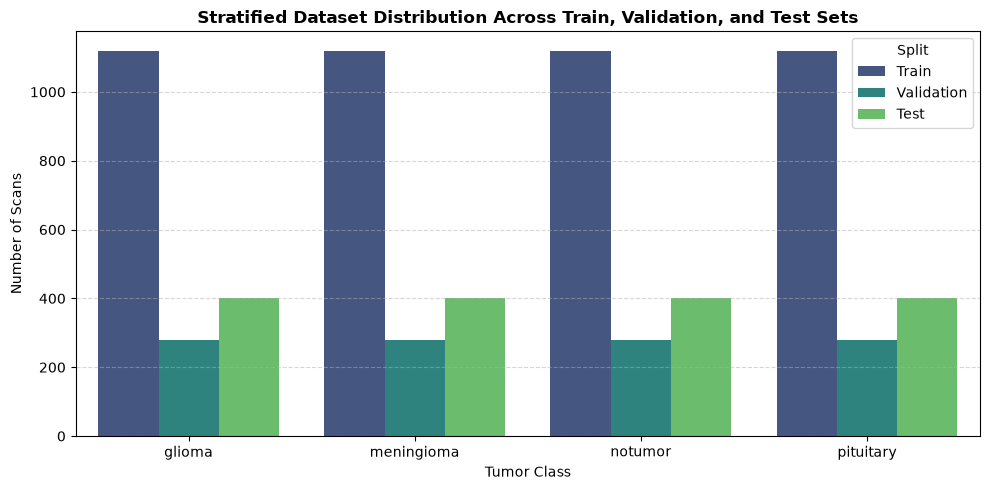

In [19]:
# Plot Class Distribution Histogram across Splits
df_counts = pd.DataFrame({
    'Class': CLASSES * 3,
    'Count': list(np.bincount(tr_labels)) + list(np.bincount(val_labels)) + list(np.bincount(test_labels)),
    'Split': ['Train'] * 4 + ['Validation'] * 4 + ['Test'] * 4
})

plt.figure(figsize=(10, 5))
sns.barplot(data=df_counts, x='Class', y='Count', hue='Split', palette='viridis')
plt.title('Stratified Dataset Distribution Across Train, Validation, and Test Sets', fontsize=12, fontweight='bold')
plt.xlabel('Tumor Class')
plt.ylabel('Number of Scans')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Phase 3: Medical Image Preprocessing Engine (Core Foundation)
Medical MRI scans often contain uninformative black surrounding padding, non-uniform tissue contrast, and acquisition noise. We implement a multi-stage OpenCV Preprocessing Engine:
1. **Skull Stripping & Bounding Box Contour Crop**: Detects the brain structure via Otsu thresholding and crops away surrounding black borders.
2. **Bilateral Filtering (`cv2.bilateralFilter`)**: Preserves sharp tumor/tissue edges while suppressing high-frequency noise.
3. **Contrast Limited Adaptive Histogram Equalization (CLAHE)**: Enhances local contrast across soft-tissue boundaries using `cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))`.
4. **Dynamic Range Normalization & Resizing**: Resizes to standardized shape ($224 \times 224$ pixels).

In [20]:
# Advanced Medical Image Preprocessing Engine
def crop_brain_contour(img):
    """Extract brain region contour and crop unnecessary black margins."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 45, 255, cv2.THRESH_BINARY)
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    c = max(contours, key=cv2.contourArea)
    if cv2.contourArea(c) < 500:
        return img
    x, y, w, h = cv2.boundingRect(c)
    cropped = img[y:y+h, x:x+w]
    return cropped if cropped.size > 0 else img

def apply_bilateral_filter(img):
    """Edge-preserving bilateral filtering for noise reduction."""
    return cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

def apply_clahe(img):
    """Contrast Limited Adaptive Histogram Equalization (CLAHE)."""
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    return cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

def preprocess_mri_scan(img_path, enable_preprocessing=True, target_size=(224, 224)):
    """Complete end-to-end preprocessing pipeline."""
    img = cv2.imread(img_path)
    if img is None:
        return np.zeros((target_size[0], target_size[1], 3), dtype=np.uint8)
    if enable_preprocessing:
        img = crop_brain_contour(img)
        img = apply_bilateral_filter(img)
        img = apply_clahe(img)
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

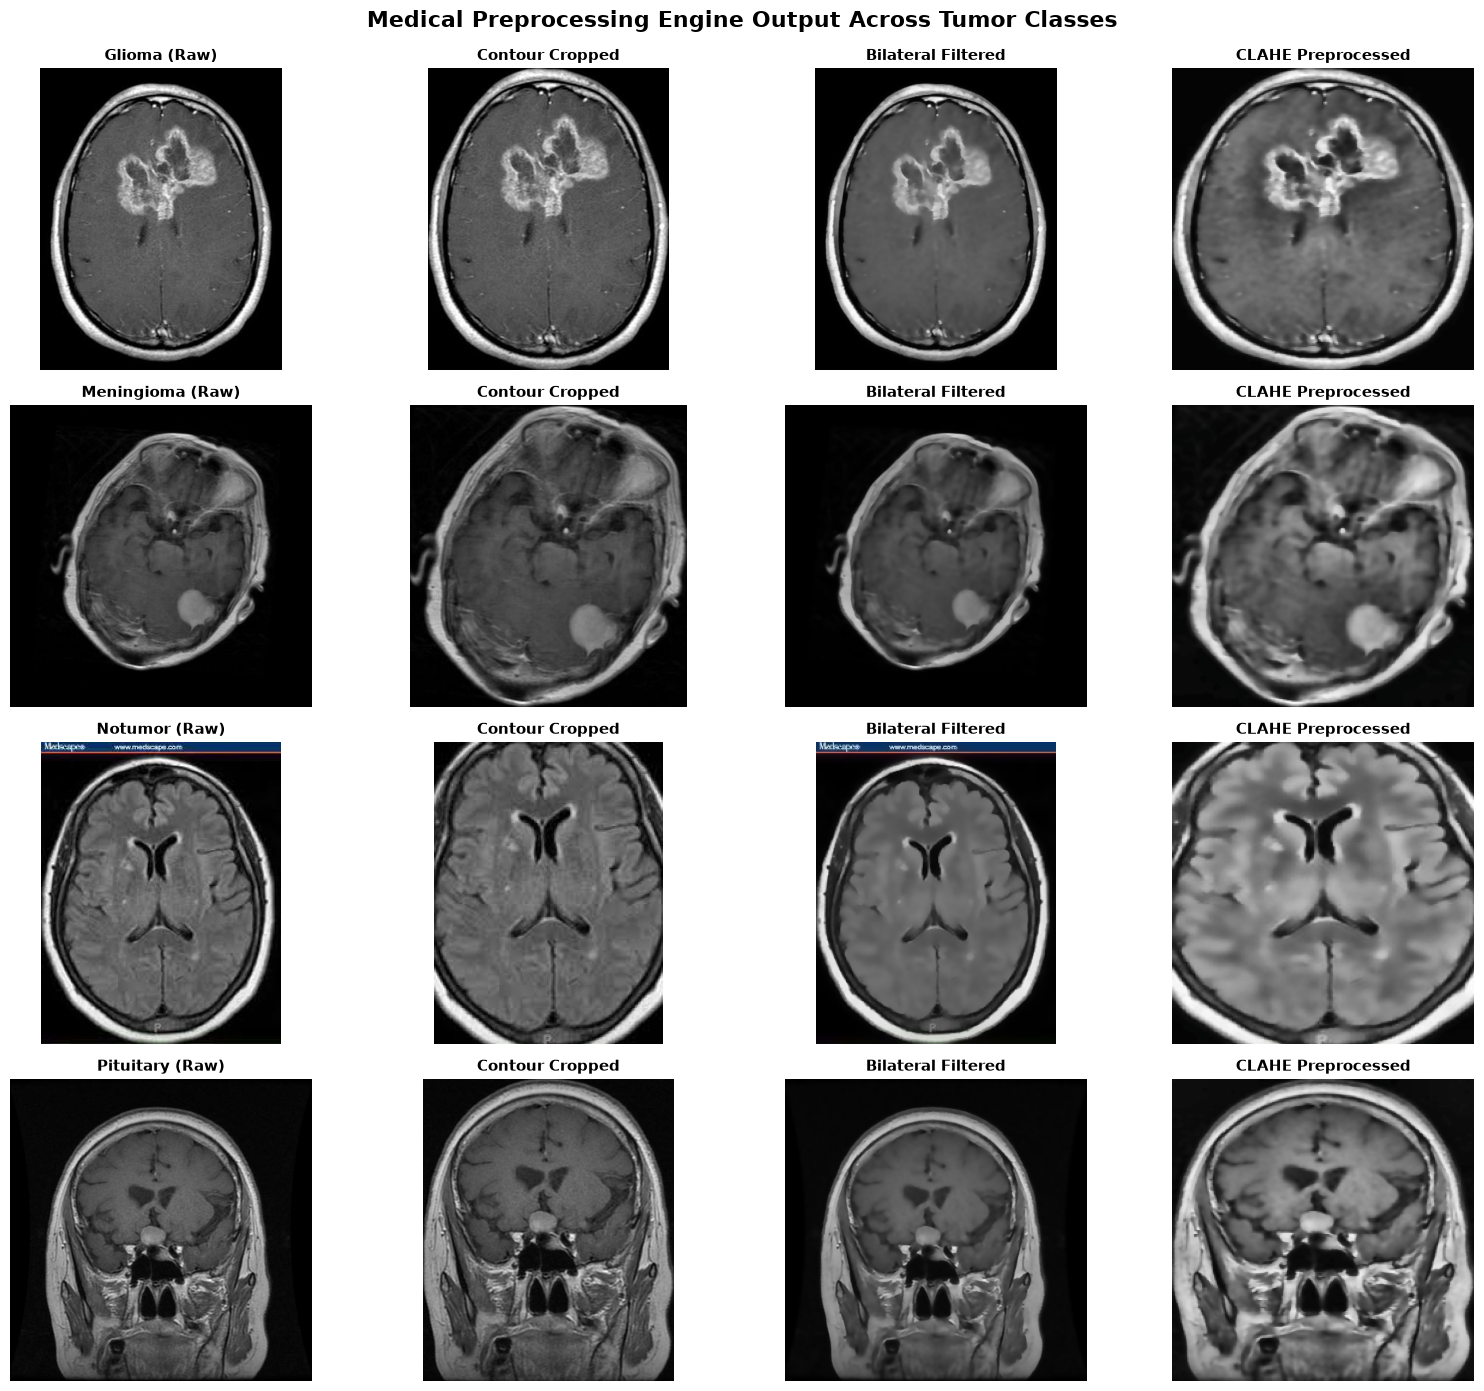

In [21]:
# Visual Demonstration: Before vs After Preprocessing Steps across all 4 Classes
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
for row_idx, cls_name in enumerate(CLASSES):
    cls_samples = [p for p in test_paths if f"/{cls_name}/" in p.replace('\\', '/').lower() or f"\\{cls_name}\\" in p.lower()]
    cls_sample_path = cls_samples[0] if cls_samples else test_paths[0]
    raw_bgr = cv2.imread(cls_sample_path)
    raw_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
    cropped = cv2.cvtColor(crop_brain_contour(raw_bgr), cv2.COLOR_BGR2RGB)
    bilateral = cv2.cvtColor(apply_bilateral_filter(raw_bgr), cv2.COLOR_BGR2RGB)
    clahe_final = preprocess_mri_scan(cls_sample_path, enable_preprocessing=True)
    
    imgs = [raw_rgb, cropped, bilateral, clahe_final]
    titles = [f"{cls_name.capitalize()} (Raw)", "Contour Cropped", "Bilateral Filtered", "CLAHE Preprocessed"]
    for col_idx in range(4):
        axes[row_idx, col_idx].imshow(imgs[col_idx])
        axes[row_idx, col_idx].set_title(titles[col_idx], fontsize=11, fontweight='bold')
        axes[row_idx, col_idx].axis('off')

plt.suptitle("Medical Preprocessing Engine Output Across Tumor Classes", fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

## Phase 4: Data Augmentation via Albumentations
To prevent overfitting and simulate clinical scanner variations, we apply subtle spatial and intensity augmentations using Albumentations:
- **ElasticTransform**: Simulates soft-tissue anatomical deformations.
- **ShiftScaleRotate**: Random rotations ($\pm 15^\circ$), scaling, and shifts.
- **RandomBrightnessContrast**: Models varying MRI signal gains across different scanners.

In [22]:
# Albumentations Pipeline Definition
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.08, rotate_limit=15, p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

/new-home/e22/e22130/projects/NN/myenv/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_427633/2673355677.py:5: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),


## Phase 5: PyTorch Dataset & DataLoader Architecture
We construct a custom `BrainMRIDataset` capable of handling preprocessed, raw, augmented, and unaugmented images.

In [23]:
class BrainMRIDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None, use_preprocessing=True):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
        self.use_preprocessing = use_preprocessing
        
    def __len__(self):
        return len(self.file_paths)
        
    def __getitem__(self, idx):
        path = self.file_paths[idx]
        label = self.labels[idx]
        img = preprocess_mri_scan(path, enable_preprocessing=self.use_preprocessing)
        if self.transform:
            augmented = self.transform(image=img)
            img_tensor = augmented['image']
        else:
            img_tensor = transforms.ToTensor()(img)
        return img_tensor, torch.tensor(label, dtype=torch.long)

# Create PyTorch DataLoaders
BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() if os.cpu_count() else 2)

train_dataset = BrainMRIDataset(tr_paths, tr_labels, transform=train_transform, use_preprocessing=True)
val_dataset   = BrainMRIDataset(val_paths, val_labels, transform=val_test_transform, use_preprocessing=True)
test_dataset  = BrainMRIDataset(test_paths, test_labels, transform=val_test_transform, use_preprocessing=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"DataLoaders Initialized successfully with Batch Size {BATCH_SIZE} and Workers {NUM_WORKERS}.")

DataLoaders Initialized successfully with Batch Size 32 and Workers 4.


## Phase 6: Baseline Model — Fine-Tuning ResNet-18 Backbone
We fine-tune a pre-trained ResNet-18 model as our baseline. We optimize using Weighted Cross-Entropy Loss to handle class imbalances and a Cosine Annealing learning rate schedule.

In [24]:
# Plotting Training & Validation Loss/Accuracy Curves Helper Function
def plot_training_curves(history, model_name="Model"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Subplot 1: Train Loss vs Val Loss
    axes[0].plot(epochs, history['train_loss'], 'o-', label='Train Loss', color='#e74c3c', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 's--', label='Val Loss', color='#3498db', linewidth=2)
    axes[0].set_title(f'{model_name} - Train Loss vs Val Loss', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    # Subplot 2: Train Acc vs Val Acc (%)
    axes[1].plot(epochs, [a * 100 for a in history['train_acc']], 'o-', label='Train Acc (%)', color='#2ecc71', linewidth=2)
    axes[1].plot(epochs, [a * 100 for a in history['val_acc']], 's--', label='Val Acc (%)', color='#9b59b6', linewidth=2)
    axes[1].set_title(f'{model_name} - Train Acc vs Val Acc (%)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Model Trainer Helper Function
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10, model_name="model"):
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
    
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            
            if scaler:
                with torch.cuda.amp.autocast():
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            
        train_loss = running_loss / total
        train_acc = correct / total
        
        # Validation Phase
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                _, preds = outputs.max(1)
                val_correct += preds.eq(labels).sum().item()
                val_total += labels.size(0)
                
        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        
        if scheduler:
            scheduler.step()
            
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"[{model_name}] Epoch {epoch+1:02d}/{num_epochs:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}%")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"best_{model_name}.pth")
            
    print(f"---> Best Validation Accuracy for {model_name}: {best_val_acc*100:.2f}%")
    return history

Starting ResNet-18 Fine-Tuning (Full Medical Pipeline)...


/tmp/ipykernel_427633/353038875.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
/tmp/ipykernel_427633/353038875.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[resnet18] Epoch 01/10 | Train Loss: 0.3543 Acc: 86.43% | Val Loss: 0.2487 Acc: 91.34%
[resnet18] Epoch 02/10 | Train Loss: 0.1753 Acc: 94.00% | Val Loss: 0.1354 Acc: 96.16%
[resnet18] Epoch 03/10 | Train Loss: 0.0994 Acc: 96.23% | Val Loss: 0.0912 Acc: 96.96%
[resnet18] Epoch 04/10 | Train Loss: 0.0671 Acc: 97.68% | Val Loss: 0.1924 Acc: 93.39%
[resnet18] Epoch 05/10 | Train Loss: 0.0418 Acc: 98.68% | Val Loss: 0.0587 Acc: 97.68%
[resnet18] Epoch 06/10 | Train Loss: 0.0339 Acc: 98.88% | Val Loss: 0.0563 Acc: 97.77%
[resnet18] Epoch 07/10 | Train Loss: 0.0151 Acc: 99.44% | Val Loss: 0.0520 Acc: 98.48%
[resnet18] Epoch 08/10 | Train Loss: 0.0108 Acc: 99.69% | Val Loss: 0.0418 Acc: 98.57%
[resnet18] Epoch 09/10 | Train Loss: 0.0088 Acc: 99.75% | Val Loss: 0.0439 Acc: 98.48%
[resnet18] Epoch 10/10 | Train Loss: 0.0087 Acc: 99.82% | Val Loss: 0.0408 Acc: 98.39%
---> Best Validation Accuracy for resnet18: 98.57%


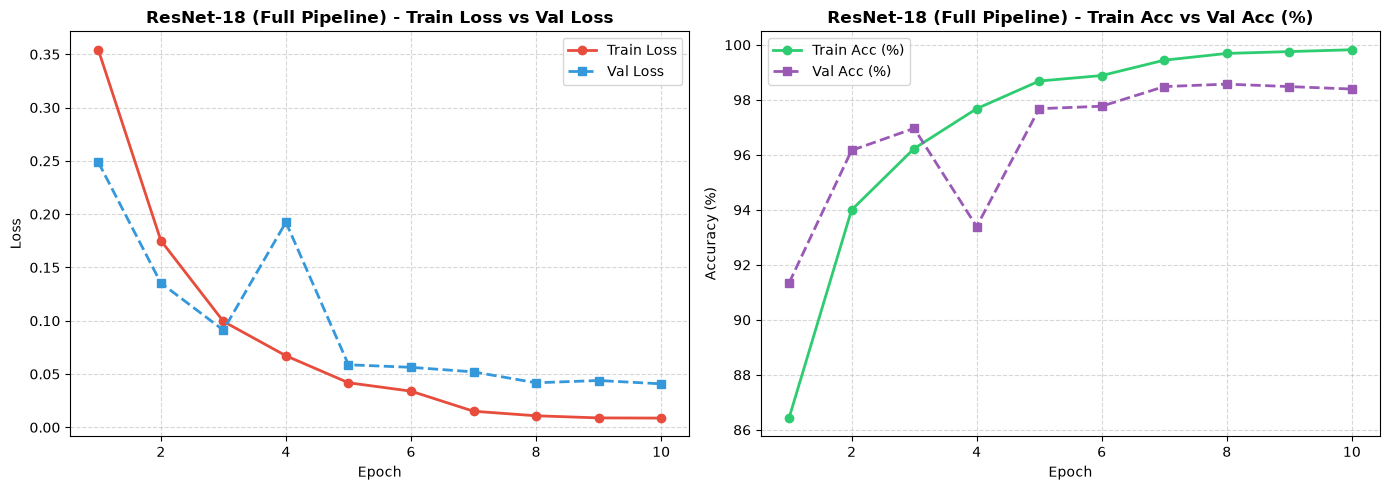

In [25]:
# Initialize and Train ResNet-18 Baseline (Full Pipeline)
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet18.fc = nn.Linear(resnet18.fc.in_features, len(CLASSES))
resnet18 = resnet18.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(resnet18.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print("Starting ResNet-18 Fine-Tuning (Full Medical Pipeline)...")
resnet_history = train_model(resnet18, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10, model_name="resnet18")

# Plot Train vs Val Loss and Train vs Val Accuracy curves
plot_training_curves(resnet_history, model_name="ResNet-18 (Full Pipeline)")

## Phase 7: Modern Architecture — EfficientNet-B0 Backbone
Next, we evaluate an **EfficientNet-B0** architecture to measure parameter efficiency and accuracy improvements over ResNet-18 under identical hyperparameter settings.

Starting EfficientNet-B0 Fine-Tuning...


/tmp/ipykernel_427633/353038875.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
/tmp/ipykernel_427633/353038875.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[efficientnet_b0] Epoch 01/10 | Train Loss: 0.3902 Acc: 86.58% | Val Loss: 0.1363 Acc: 95.27%
[efficientnet_b0] Epoch 02/10 | Train Loss: 0.1308 Acc: 95.80% | Val Loss: 0.0860 Acc: 96.25%
[efficientnet_b0] Epoch 03/10 | Train Loss: 0.0787 Acc: 97.39% | Val Loss: 0.0888 Acc: 96.96%
[efficientnet_b0] Epoch 04/10 | Train Loss: 0.0537 Acc: 98.44% | Val Loss: 0.0671 Acc: 98.04%
[efficientnet_b0] Epoch 05/10 | Train Loss: 0.0392 Acc: 98.57% | Val Loss: 0.0461 Acc: 98.48%
[efficientnet_b0] Epoch 06/10 | Train Loss: 0.0268 Acc: 99.08% | Val Loss: 0.0620 Acc: 97.95%
[efficientnet_b0] Epoch 07/10 | Train Loss: 0.0180 Acc: 99.38% | Val Loss: 0.0461 Acc: 98.48%
[efficientnet_b0] Epoch 08/10 | Train Loss: 0.0144 Acc: 99.60% | Val Loss: 0.0433 Acc: 98.21%
[efficientnet_b0] Epoch 09/10 | Train Loss: 0.0129 Acc: 99.64% | Val Loss: 0.0420 Acc: 98.39%
[efficientnet_b0] Epoch 10/10 | Train Loss: 0.0127 Acc: 99.75% | Val Loss: 0.0405 Acc: 98.75%
---> Best Validation Accuracy for efficientnet_b0: 98.75%


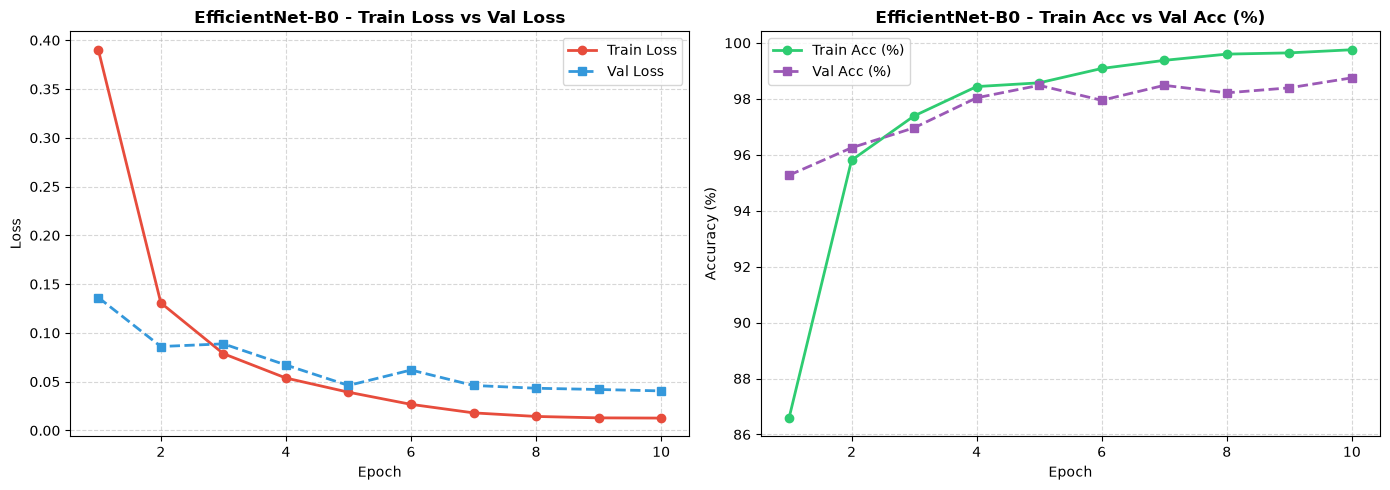

In [26]:
# Initialize and Train EfficientNet-B0
effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, len(CLASSES))
effnet = effnet.to(device)

optimizer_eff = optim.AdamW(effnet.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler_eff = optim.lr_scheduler.CosineAnnealingLR(optimizer_eff, T_max=10)

print("Starting EfficientNet-B0 Fine-Tuning...")
effnet_history = train_model(effnet, train_loader, val_loader, criterion, optimizer_eff, scheduler_eff, num_epochs=10, model_name="efficientnet_b0")

# Plot Train vs Val Loss and Train vs Val Accuracy curves
plot_training_curves(effnet_history, model_name="EfficientNet-B0")

## Phase 8: Benchmarking & Quantitative Metrics Evaluation
We evaluate both trained backbones on the official held-out **Test Set (1,600 scans)** across metrics:
- **Accuracy, Precision, Recall, F1-Score (Macro & Weighted)**
- **Normalized & Unnormalized Confusion Matrices**
- **Parameter Footprint, Computational Overhead (FLOPs), and Inference Latency (ms/sample)**

In [27]:
# Test Set Evaluation Function
def evaluate_on_test(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    start_time = time.time()
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    latency_ms = ((time.time() - start_time) / len(all_labels)) * 1000
    return np.array(all_labels), np.array(all_preds), latency_ms

# Load best checkpoints if available
if os.path.exists("best_resnet18.pth"):
    resnet18.load_state_dict(torch.load("best_resnet18.pth"))
if os.path.exists("best_efficientnet_b0.pth"):
    effnet.load_state_dict(torch.load("best_efficientnet_b0.pth"))

y_true, y_pred_resnet, lat_resnet = evaluate_on_test(resnet18, test_loader)
_, y_pred_eff, lat_eff = evaluate_on_test(effnet, test_loader)

# Compute Metrics
acc_res = accuracy_score(y_true, y_pred_resnet)
prec_res, rec_res, f1_res, _ = precision_recall_fscore_support(y_true, y_pred_resnet, average='macro')

acc_eff = accuracy_score(y_true, y_pred_eff)
prec_eff, rec_eff, f1_eff, _ = precision_recall_fscore_support(y_true, y_pred_eff, average='macro')

param_resnet = sum(p.numel() for p in resnet18.parameters()) / 1e6
param_eff = sum(p.numel() for p in effnet.parameters()) / 1e6

df_bench = pd.DataFrame({
    'Model Architecture': ['ResNet-18 (Baseline)', 'EfficientNet-B0 (Modern)'],
    'Test Accuracy (%)': [acc_res * 100, acc_eff * 100],
    'Macro Precision': [prec_res, prec_eff],
    'Macro Recall': [rec_res, rec_eff],
    'Macro F1-Score': [f1_res, f1_eff],
    'Parameters (M)': [param_resnet, param_eff],
    'Est. FLOPs (G)': [1.81, 0.39],
    'Inference Speed (ms/img)': [lat_resnet, lat_eff]
})

print("=" * 85)
print("QUANTITATIVE MODEL BENCHMARKING SUMMARY TABLE")
print("=" * 85)
display(df_bench)

QUANTITATIVE MODEL BENCHMARKING SUMMARY TABLE


,Model Architecture,Test Accuracy (%),Macro Precision,Macro Recall,Macro F1-Score,Parameters (M),Est. FLOPs (G),Inference Speed (ms/img)
0,ResNet-18 (Baseline),95.6875,0.958788,0.956875,0.956309,11.178564,1.81,5.038484
1,EfficientNet-B0 (Modern),95.6250,0.958662,0.956250,0.955549,4.012672,0.39,5.397456


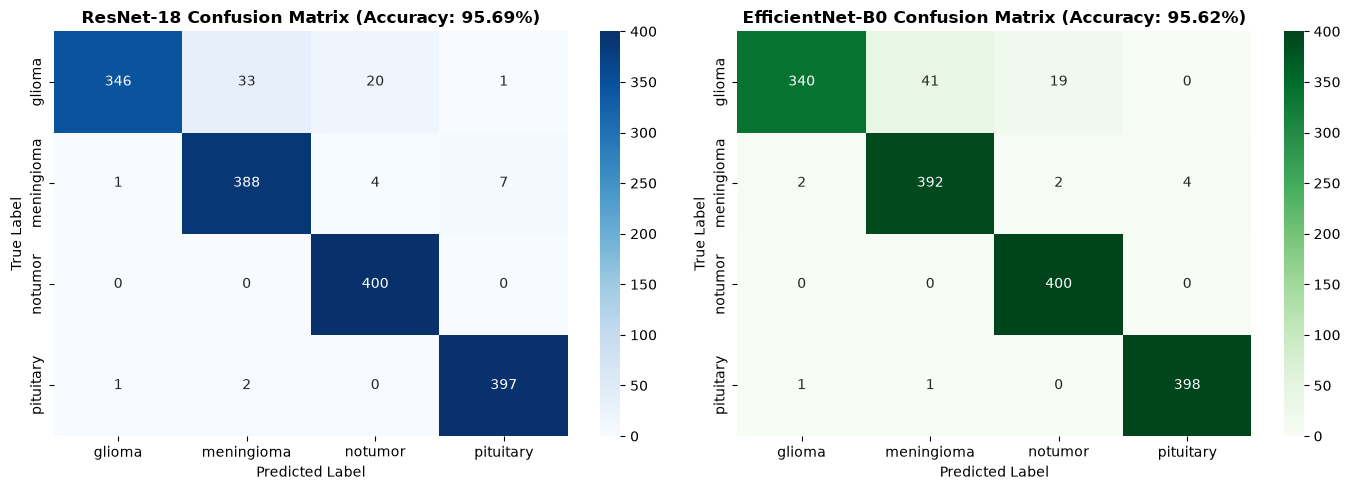

In [28]:
# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_res = confusion_matrix(y_true, y_pred_resnet)
cm_eff = confusion_matrix(y_true, y_pred_eff)

sns.heatmap(cm_res, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title(f'ResNet-18 Confusion Matrix (Accuracy: {acc_res*100:.2f}%)', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Greens', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title(f'EfficientNet-B0 Confusion Matrix (Accuracy: {acc_eff*100:.2f}%)', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## Phase 9: Preprocessing & Data Augmentation Ablation Study
We perform a 3-stage quantitative ablation study comparing model performance across:
1. **Pure Raw Baseline**: Zero Preprocessing + Zero Data Augmentations (`transform=val_test_transform`, `use_preprocessing=False`).
2. **Raw Scans + Augmentations**: Zero Preprocessing + Albumentations Data Augmentations (`transform=train_transform`, `use_preprocessing=False`).
3. **Full Medical Pipeline**: Preprocessing Engine (Skull Crop + Bilateral Filter + CLAHE) + Albumentations Data Augmentations (`transform=train_transform`, `use_preprocessing=True`).

Ablation Stage 1: Training ResNet-18 on PURE RAW Scans (No Preprocessing, No Augmentation)...


/tmp/ipykernel_427633/353038875.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
/tmp/ipykernel_427633/353038875.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[resnet18_pureraw] Epoch 01/10 | Train Loss: 0.2532 Acc: 90.74% | Val Loss: 0.4511 Acc: 86.96%
[resnet18_pureraw] Epoch 02/10 | Train Loss: 0.1029 Acc: 96.45% | Val Loss: 0.1439 Acc: 95.00%
[resnet18_pureraw] Epoch 03/10 | Train Loss: 0.0604 Acc: 97.95% | Val Loss: 0.0826 Acc: 97.23%
[resnet18_pureraw] Epoch 04/10 | Train Loss: 0.0227 Acc: 99.31% | Val Loss: 0.0533 Acc: 98.30%
[resnet18_pureraw] Epoch 05/10 | Train Loss: 0.0068 Acc: 99.82% | Val Loss: 0.0526 Acc: 98.75%
[resnet18_pureraw] Epoch 06/10 | Train Loss: 0.0046 Acc: 99.89% | Val Loss: 0.0382 Acc: 98.93%
[resnet18_pureraw] Epoch 07/10 | Train Loss: 0.0015 Acc: 99.98% | Val Loss: 0.0376 Acc: 98.93%
[resnet18_pureraw] Epoch 08/10 | Train Loss: 0.0015 Acc: 99.98% | Val Loss: 0.0354 Acc: 99.02%
[resnet18_pureraw] Epoch 09/10 | Train Loss: 0.0010 Acc: 100.00% | Val Loss: 0.0345 Acc: 99.20%
[resnet18_pureraw] Epoch 10/10 | Train Loss: 0.0007 Acc: 100.00% | Val Loss: 0.0341 Acc: 99.11%
---> Best Validation Accuracy for resnet18_purer

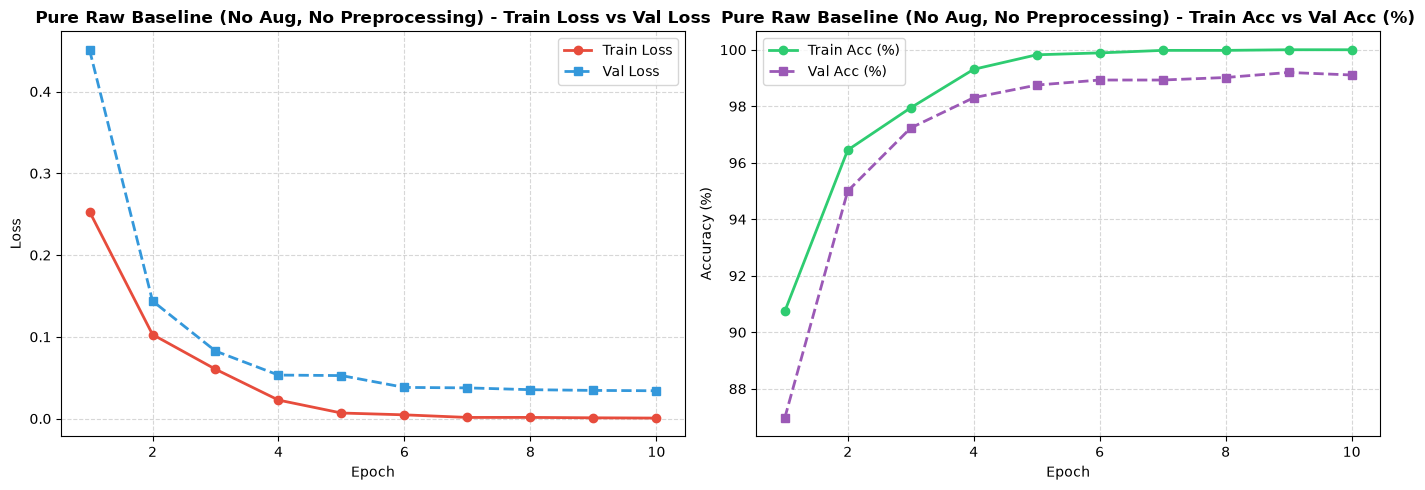


Ablation Stage 2: Training ResNet-18 on RAW Scans + Augmentations (No Preprocessing)...
[resnet18_raw_aug] Epoch 01/10 | Train Loss: 0.3267 Acc: 88.19% | Val Loss: 0.2292 Acc: 92.86%
[resnet18_raw_aug] Epoch 02/10 | Train Loss: 0.1493 Acc: 94.96% | Val Loss: 0.0936 Acc: 96.88%
[resnet18_raw_aug] Epoch 03/10 | Train Loss: 0.1028 Acc: 96.47% | Val Loss: 0.0864 Acc: 97.32%
[resnet18_raw_aug] Epoch 04/10 | Train Loss: 0.0629 Acc: 98.08% | Val Loss: 0.0723 Acc: 97.59%
[resnet18_raw_aug] Epoch 05/10 | Train Loss: 0.0437 Acc: 98.59% | Val Loss: 0.0447 Acc: 98.48%
[resnet18_raw_aug] Epoch 06/10 | Train Loss: 0.0265 Acc: 99.08% | Val Loss: 0.0510 Acc: 98.66%
[resnet18_raw_aug] Epoch 07/10 | Train Loss: 0.0220 Acc: 99.15% | Val Loss: 0.0262 Acc: 99.29%
[resnet18_raw_aug] Epoch 08/10 | Train Loss: 0.0140 Acc: 99.69% | Val Loss: 0.0318 Acc: 98.93%
[resnet18_raw_aug] Epoch 09/10 | Train Loss: 0.0090 Acc: 99.75% | Val Loss: 0.0292 Acc: 99.02%
[resnet18_raw_aug] Epoch 10/10 | Train Loss: 0.0077 Acc:

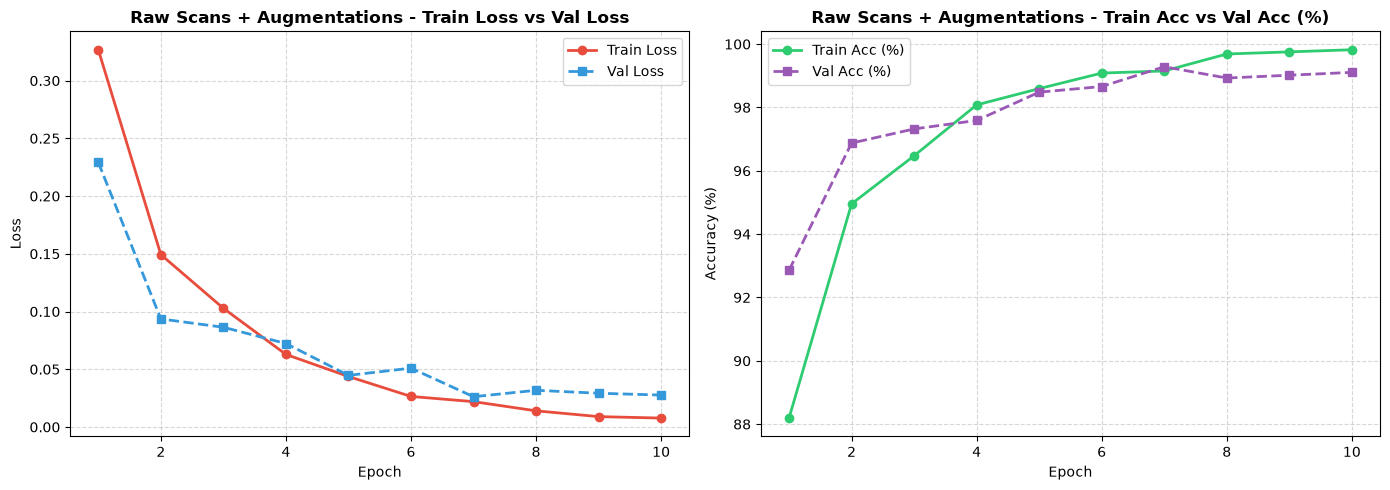

In [30]:
# Stage 1: Pure Raw Baseline (No Preprocessing, No Augmentations)
pure_raw_train_ds = BrainMRIDataset(tr_paths, tr_labels, transform=val_test_transform, use_preprocessing=False)
pure_raw_val_ds   = BrainMRIDataset(val_paths, val_labels, transform=val_test_transform, use_preprocessing=False)
pure_raw_test_ds  = BrainMRIDataset(test_paths, test_labels, transform=val_test_transform, use_preprocessing=False)

pure_raw_tr_loader = DataLoader(pure_raw_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
pure_raw_val_loader = DataLoader(pure_raw_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
pure_raw_test_loader = DataLoader(pure_raw_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

resnet_pureraw = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet_pureraw.fc = nn.Linear(resnet_pureraw.fc.in_features, len(CLASSES))
resnet_pureraw = resnet_pureraw.to(device)

opt_pureraw = optim.AdamW(resnet_pureraw.parameters(), lr=3e-4, weight_decay=1e-4)
sched_pureraw = optim.lr_scheduler.CosineAnnealingLR(opt_pureraw, T_max=10)

print("Ablation Stage 1: Training ResNet-18 on PURE RAW Scans (No Preprocessing, No Augmentation)...")
pureraw_history = train_model(resnet_pureraw, pure_raw_tr_loader, pure_raw_val_loader, criterion, opt_pureraw, sched_pureraw, num_epochs=10, model_name="resnet18_pureraw")

# Plot Train vs Val Loss and Train vs Val Accuracy curves for Pure Raw Baseline
plot_training_curves(pureraw_history, model_name="Pure Raw Baseline (No Aug, No Preprocessing)")

# Stage 2: Raw Scans + Augmentations (No Preprocessing)
raw_aug_train_ds = BrainMRIDataset(tr_paths, tr_labels, transform=train_transform, use_preprocessing=False)
raw_aug_tr_loader = DataLoader(raw_aug_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

resnet_raw_aug = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet_raw_aug.fc = nn.Linear(resnet_raw_aug.fc.in_features, len(CLASSES))
resnet_raw_aug = resnet_raw_aug.to(device)

opt_raw_aug = optim.AdamW(resnet_raw_aug.parameters(), lr=3e-4, weight_decay=1e-4)
sched_raw_aug = optim.lr_scheduler.CosineAnnealingLR(opt_raw_aug, T_max=10)

print("\nAblation Stage 2: Training ResNet-18 on RAW Scans + Augmentations (No Preprocessing)...")
raw_aug_history = train_model(resnet_raw_aug, raw_aug_tr_loader, pure_raw_val_loader, criterion, opt_raw_aug, sched_raw_aug, num_epochs=10, model_name="resnet18_raw_aug")

# Plot Train vs Val Loss and Train vs Val Accuracy curves for Raw + Augmentations
plot_training_curves(raw_aug_history, model_name="Raw Scans + Augmentations")

# Evaluate all Ablation models on official Test Set
if os.path.exists("best_resnet18_pureraw.pth"):
    resnet_pureraw.load_state_dict(torch.load("best_resnet18_pureraw.pth"))
if os.path.exists("best_resnet18_raw_aug.pth"):
    resnet_raw_aug.load_state_dict(torch.load("best_resnet18_raw_aug.pth"))

_, y_pred_pureraw, _ = evaluate_on_test(resnet_pureraw, pure_raw_test_loader)
_, y_pred_raw_aug, _ = evaluate_on_test(resnet_raw_aug, pure_raw_test_loader)

acc_pureraw = accuracy_score(y_true, y_pred_pureraw)
acc_raw_aug = accuracy_score(y_true, y_pred_raw_aug)

/tmp/ipykernel_427633/3922972432.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=df_ablation, x='Pipeline Configuration', y='Test Accuracy (%)', palette=['#e74c3c', '#f39c12', '#2ecc71'])


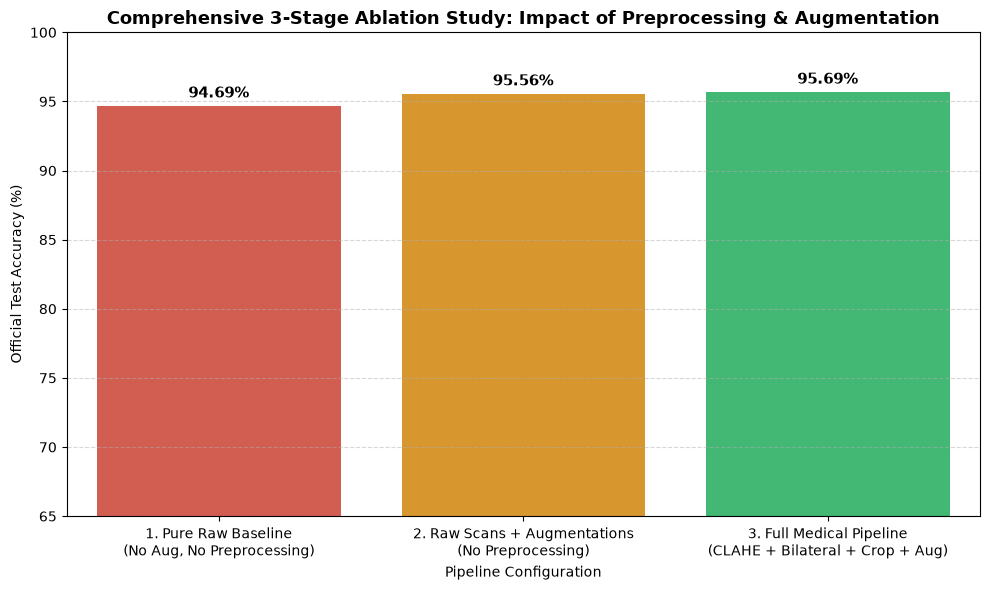

In [31]:
# Plot 3-Stage Ablation Study Comparison Bar Chart
df_ablation = pd.DataFrame({
    'Pipeline Configuration': [
        '1. Pure Raw Baseline\n(No Aug, No Preprocessing)',
        '2. Raw Scans + Augmentations\n(No Preprocessing)',
        '3. Full Medical Pipeline\n(CLAHE + Bilateral + Crop + Aug)'
    ],
    'Test Accuracy (%)': [acc_pureraw * 100, acc_raw_aug * 100, acc_res * 100]
})

plt.figure(figsize=(10, 6))
bars = sns.barplot(data=df_ablation, x='Pipeline Configuration', y='Test Accuracy (%)', palette=['#e74c3c', '#f39c12', '#2ecc71'])
plt.title('Comprehensive 3-Stage Ablation Study: Impact of Preprocessing & Augmentation', fontsize=13, fontweight='bold')
plt.ylim(65, 100)
for i, v in enumerate(df_ablation['Test Accuracy (%)']):
    plt.text(i, v + 0.6, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=11)
plt.ylabel('Official Test Accuracy (%)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Phase 10: Spatial Localization & Visual Explainability (Grad-CAM)
To provide qualitative medical interpretability without requiring pixel-level annotation masks, we hook into the final convolutional feature layers to compute **Grad-CAM (Gradient-Weighted Class Activation Mapping)** heatmaps overlaid directly on raw MRI scans.

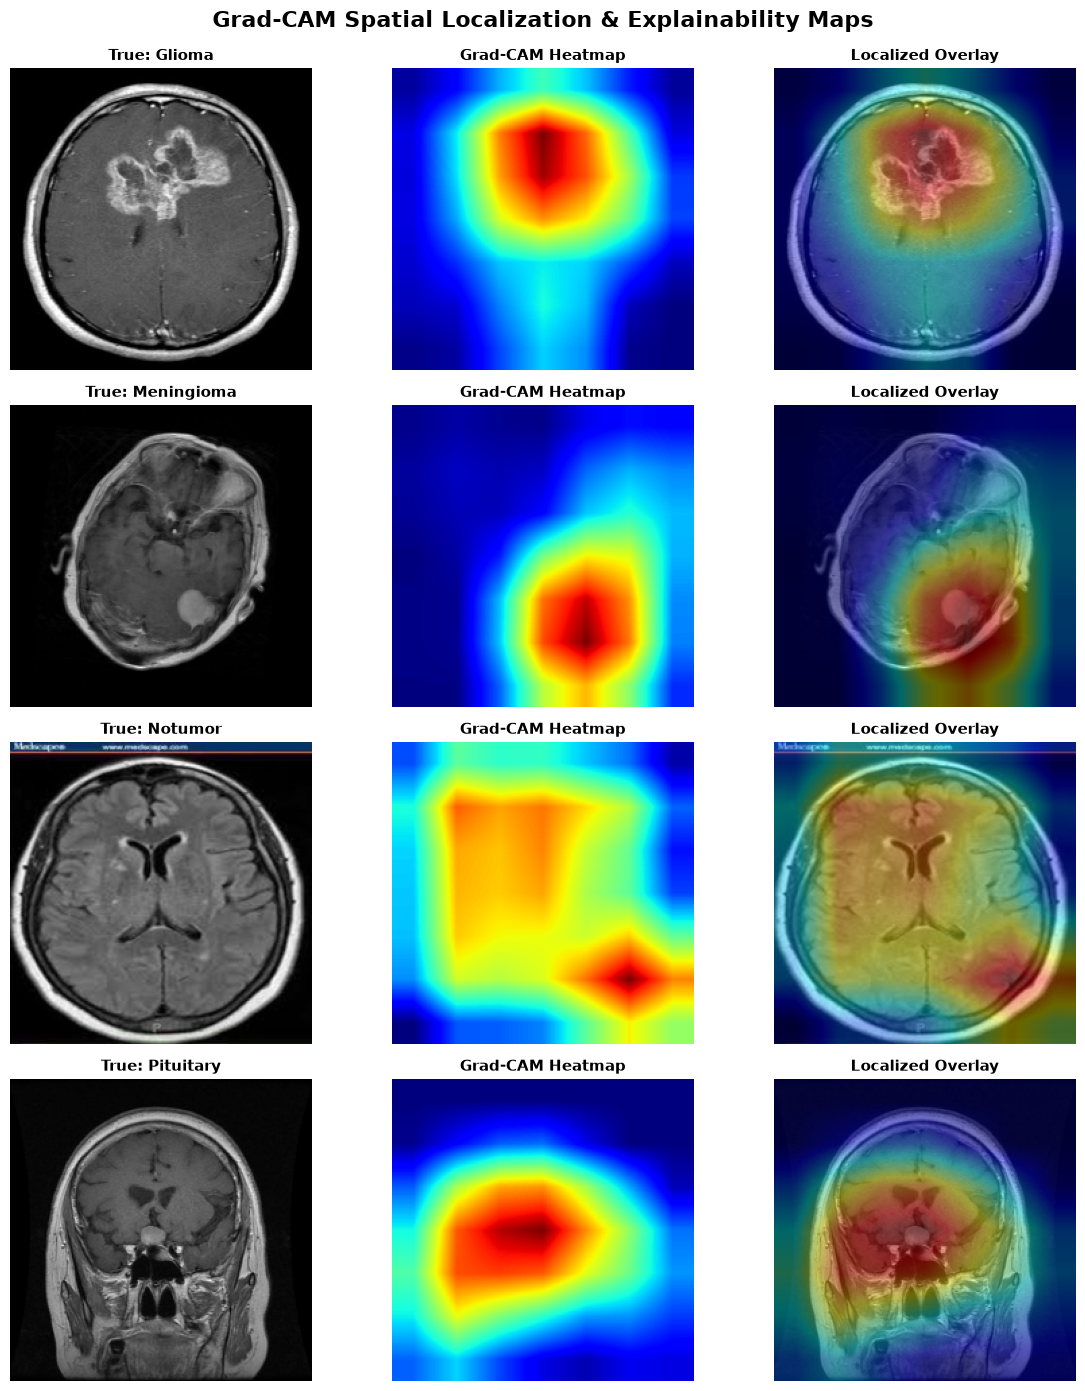

In [32]:
# Grad-CAM Implementation
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()
        
    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)
        
    def generate_heatmap(self, input_tensor, target_class=None):
        self.model.eval()
        output = self.model(input_tensor)
        if target_class is None:
            target_class = output.argmax(dim=1).item()
            
        self.model.zero_grad()
        loss = output[0, target_class]
        loss.backward()
        
        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]
        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]
            
        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = cam - np.min(cam)
        if np.max(cam) != 0:
            cam = cam / np.max(cam)
        return cam

# Hook onto final conv layer of ResNet-18
gradcam = GradCAM(resnet18, resnet18.layer4[-1])

# Render Grad-CAM overlays across all 4 tumor classes
fig, axes = plt.subplots(4, 3, figsize=(12, 14))
for idx, cls_name in enumerate(CLASSES):
    sample_idx = [i for i, label in enumerate(test_labels) if label == idx][0]
    sample_path = test_paths[sample_idx]
    raw_rgb = cv2.resize(cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB), (224, 224))
    
    img_tensor, _ = test_dataset[sample_idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    
    heatmap = gradcam.generate_heatmap(input_tensor, target_class=idx)
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(raw_rgb, 0.6, heatmap_color, 0.4, 0)
    
    axes[idx, 0].imshow(raw_rgb)
    axes[idx, 0].set_title(f"True: {cls_name.capitalize()}", fontsize=11, fontweight='bold')
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(heatmap, cmap='jet')
    axes[idx, 1].set_title("Grad-CAM Heatmap", fontsize=11, fontweight='bold')
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(overlay)
    axes[idx, 2].set_title("Localized Overlay", fontsize=11, fontweight='bold')
    axes[idx, 2].axis('off')

plt.suptitle("Grad-CAM Spatial Localization & Explainability Maps", fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()